In [2]:
!pip install yfinance --upgrade --no-cache-dir

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tickers = ['SPY', 'AGG', 'GLD', 'QQQ', 'VNQ']

In [4]:
data = yf.download(tickers, start='2019-01-01', end='2024-12-31')['Close']
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AGG,GLD,QQQ,SPY,VNQ
Date,,,,,
2019-01-02,86.043541,121.330002,147.878296,223.805954,55.038429
2019-01-03,86.398788,122.430000,143.047104,218.465317,55.423206
2019-01-04,86.140450,121.440002,149.167313,225.782974,56.072052
2019-01-07,85.995102,121.860001,150.943237,227.563171,56.622822
2019-01-08,85.930481,121.529999,152.308578,229.701248,57.792236


In [5]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AGG,GLD,QQQ,SPY,VNQ
Date,,,,,
2019-01-03,0.004129,0.009066,-0.032670,-0.023863,0.006991
2019-01-04,-0.002990,-0.008086,0.042785,0.033496,0.011707
2019-01-07,-0.001687,0.003458,0.011906,0.007885,0.009823
2019-01-08,-0.000751,-0.002708,0.009045,0.009396,0.020653
2019-01-09,0.000846,0.006418,0.008150,0.004673,-0.001436


In [6]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,AGG,GLD,QQQ,SPY,VNQ
Ticker,,,,,
AGG,1.000000,0.377389,0.160197,0.158367,0.278791
GLD,0.377389,1.000000,0.134614,0.123357,0.176101
QQQ,0.160197,0.134614,1.000000,0.931494,0.629281
SPY,0.158367,0.123357,0.931494,1.000000,0.782031
VNQ,0.278791,0.176101,0.629281,0.782031,1.000000


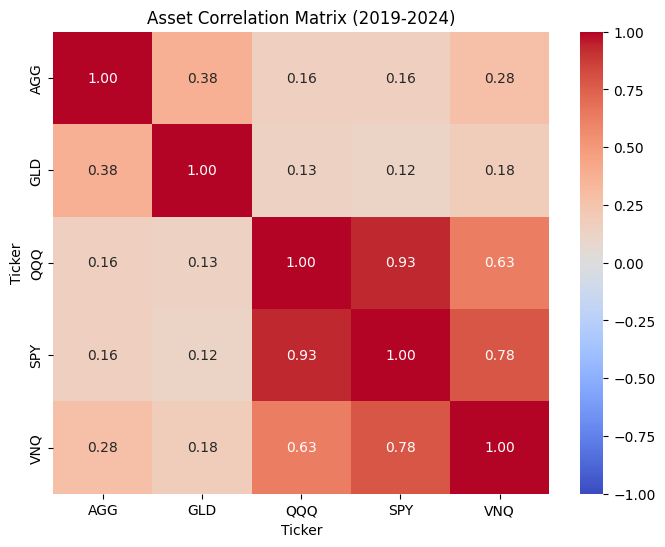

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Asset Correlation Matrix (2019-2024)')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.04  # approximate current risk-free rate (e.g., T-bills)
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
})
summary

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
AGG,0.012807,0.063769,-0.426427
GLD,0.125640,0.149518,0.572773
QQQ,0.237272,0.243364,0.810603
SPY,0.178469,0.198419,0.697863
VNQ,0.098070,0.238166,0.243821


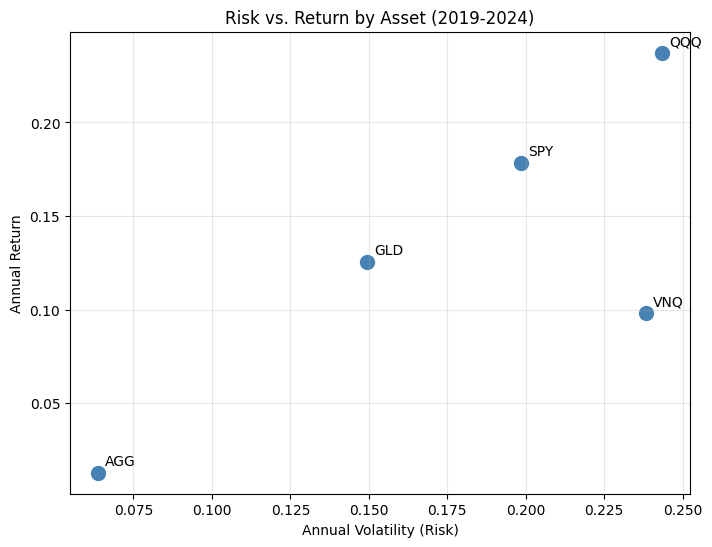

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(summary['Annual Volatility'], summary['Annual Return'], s=100, color='steelblue')

for ticker in summary.index:
    plt.annotate(ticker,
                 (summary.loc[ticker, 'Annual Volatility'], summary.loc[ticker, 'Annual Return']),
                 xytext=(5, 5), textcoords='offset points')

plt.title('Risk vs. Return by Asset (2019-2024)')
plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return')
plt.grid(alpha=0.3)
plt.savefig('risk_return_scatter.png', dpi=150, bbox_inches='tight')
plt.show()